# Supervised learning in astronomy: classification + regression (tabular ML)

In this tutorial we will work with a **tabular** dataset of astronomical sources and use it to:

- build a **classification** model (BD / LPV / YSO / Galaxy),
- then reuse the same workflow for **regression** (predicting a continuous target: stellar class for example),
- and discuss good practice: splitting, leakage, preprocessing, metrics, tuning, interpretability and reliability.


# 1) Load the dataset

We will load a parquet file containing a pre-made catalogue.

**Important idea:** most ML bugs are boring:
wrong column, wrong split, leakage or broken data types.
So we start with sanity checks.

In [54]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

In [ ]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = r"C:\Git projects\PhDSchool2026Napoli\AI-in-astro-tutorial-supervised\Prelim_balanced_catalogue_PS1_with_cut_2MASS_WISE_newUCD.parquet"

# DATA_PATH = "https://github.com/iamaleksandra/AI-in-astro-tutorial-supervised/raw/main/data/Prelim_balanced_catalogue_PS1_with_cut_2MASS_WISE_newUCD.parquet"

df = pd.read_parquet(DATA_PATH)
df.head()

,RAJ2000,DEJ2000,Class,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,...,W1,W1err,W2,W2err,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag
0,266.38238,-24.27142,Var,20.4466,0.0072,17.7346,0.0208,14.8988,0.0224,12.6510,...,6.915,0.010,7.537,0.013,9.672,0.027,8.399,0.049,7.759,0.033
1,304.21691,30.94242,Var,16.4922,0.0075,14.2077,0.0014,12.1450,NaN,11.1020,...,6.653,0.016,6.788,0.008,8.651,0.021,7.393,0.024,6.916,0.020
2,359.68844,55.66797,Var,15.5176,0.0104,13.7179,0.0016,11.5198,0.0422,11.9317,...,6.476,0.019,6.063,0.010,7.616,0.024,6.638,0.055,6.204,0.017
3,6.99508,47.69643,Var,14.4898,0.0190,12.3170,NaN,10.5530,NaN,9.5100,...,6.255,0.024,5.816,0.011,7.256,0.021,6.351,0.023,5.945,0.017
4,286.07637,-9.41763,Var,20.0832,0.0406,17.1633,0.1090,12.5760,NaN,11.4200,...,7.208,0.022,6.460,0.009,8.898,0.030,7.814,0.047,7.193,0.038


In [4]:
# Basic info
display(df.sample(5, random_state=RANDOM_STATE))
print("\nColumns:", len(df.columns))
display(df.dtypes.value_counts())

,RAJ2000,DEJ2000,Class,gmag,e_gmag,rmag,e_rmag,imag,e_imag,zmag,...,W1,W1err,W2,W2err,Jmag,e_Jmag,Hmag,e_Hmag,Kmag,e_Kmag
9923,305.211050,39.804870,canYSO,28.9740,NaN,25.0830,NaN,22.0790,NaN,20.9055,...,12.895,0.035,12.618,0.041,16.398,NaN,14.846,0.083,14.054,0.078
7013,133.823393,5.966581,Galaxy,NaN,NaN,NaN,NaN,19.3655,0.0432,19.4706,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4779,84.966700,-0.983800,UCD,NaN,NaN,21.2317,0.0542,19.0754,0.1091,17.1562,...,11.891,0.012,11.604,0.009,14.033,0.031,13.104,0.024,12.527,0.024
1950,275.680000,-22.467610,Var,20.7303,0.0631,17.8014,0.0108,14.5212,0.0015,13.7009,...,6.974,0.020,6.724,0.010,10.177,0.023,8.754,0.036,7.922,0.023
2513,284.995830,-11.243200,Var,16.4896,0.0592,14.5304,0.0368,13.3100,NaN,11.6680,...,7.148,0.018,7.010,0.010,8.513,0.020,7.470,0.042,7.061,0.031



Columns: 23


float64    22
object      1
dtype: int64

In [6]:
df.columns

Index(['RAJ2000', 'DEJ2000', 'Class', 'gmag', 'e_gmag', 'rmag', 'e_rmag',
       'imag', 'e_imag', 'zmag', 'e_zmag', 'ymag', 'e_ymag', 'W1', 'W1err',
       'W2', 'W2err', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag', 'Kmag', 'e_Kmag'],
      dtype='object')

# 2) Train / Validation / Test Split

Before doing any preprocessing or modelling, we must split the data.

Why?

Because if we:
- scale using the full dataset,
- impute using the full dataset,
- tune hyperparameters using the full set,

we create **data leakage**. Leakage makes the model look better than it really is.

### Strategy

We will:

- Remove coordinates (RAJ2000, DEJ2000)
- Define X and y
- Use a **stratified split** (important for multi-class classification)
- Create:
    - Train (60%)
    - Validation (20%)
    - Test (20%)

We keep the test set untouched until the very end.

In [103]:
LABEL_COL = 'Class'

y_str = df[LABEL_COL]

# Encode to integers 0..K-1
le = LabelEncoder()
y = le.fit_transform(y_str)

# Save mapping for later interpretation
class_names = list(le.classes_)
class_mapping = dict(zip(class_names, range(len(class_names))))

# Drop label from features
X = df.drop(columns=[LABEL_COL, 'RAJ2000', 'DEJ2000'])

print("X shape:", X.shape)
display(y_str.value_counts(dropna=False).head(20))

X shape: (10246, 20)


Var       4000
UCD       2831
canYSO    2147
Galaxy    1268
Name: Class, dtype: int64

In [59]:
# First split: train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# Second split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25, 
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (6147, 20)
Val size: (2049, 20)
Test size: (2050, 20)


## Why do we need a validation set?

If we only split into **train** and **test**, this works only if we train once and never adjust anything.

But in practice we always:
- tune hyperparameters
- compare models
- change preprocessing
- engineer features

If we look at the test performance and then modify the model, the test set has influenced model design and it is no longer a true test set.


### Roles of each split

- **Train** --> fit model parameters  
- **Validation/calibration** --> choose hyperparameters and make decisions OR for calibration in conformal predictions (we will see later)  
- **Test** --> final, unbiased evaluation  

The test set must simulate unseen future data, if it influences training, performance estimates become optimistic.

### What if we have limited data?

Instead of using a fixed validation set, we can use **k-fold cross-validation**.

How it works:

1. Split the training data into k folds.
2. Train on (k−1) folds.
3. Validate on the remaining fold.
4. Repeat k times.
5. Average the validation performance.

This allows every sample to be used for both training and validation.

Cross-validation replaces the **validation set**, but **not the test set**.

! We still keep a final test set untouched for one final evaluation.

# 3) Data preprocessing (scaling and missing values) and feature engineering

Before training any model, we must prepare the data.

For tabular astronomical data, preprocessing usually includes:

1. Handling missing values  
2. Feature scaling (for some models)  
3. Feature engineering (e.g. colors)  

Important principle:

All preprocessing steps must be fitted ONLY on the training set.
Validation and test sets must be transformed using parameters learned from training.

In [104]:
train_with_class = X_train.copy()
train_with_class["Class"] = le.inverse_transform(y_train)

# Compute missing fraction per class
missing_by_class = (
    train_with_class
    .groupby("Class")
    .apply(lambda df_: df_.isna().mean())
)

missing_by_class.T

Class,Galaxy,UCD,Var,canYSO
gmag,0.138158,0.920541,0.112500,0.545807
e_gmag,0.239474,0.920541,0.258750,0.916925
rmag,0.096053,0.785756,0.092083,0.443323
e_rmag,0.185526,0.785756,0.395000,0.673913
imag,0.000000,0.544438,0.000000,0.000000
e_imag,0.125000,0.544438,0.531667,0.061335
zmag,0.084211,0.377869,0.041250,0.009317
e_zmag,0.265789,0.377869,0.693333,0.022516
ymag,0.000000,0.327840,0.000000,0.000000
e_ymag,0.328947,0.327840,0.600000,0.013199


## Interpretation: missingness is not random

The table above shows the fraction of missing values per feature and per class.

We observe that missingness strongly depends on class:

- UCDs are mostly missing in optical bands (g, r, i),
  but almost complete in W1/W2.
- Galaxies show the opposite behaviour:
  optical mostly present, W1/W2 mostly missing.
- YSO and Variables have different missing patterns again.

This means missingness is structured, not random.


### Why this matters

If missing values depend on class, then missingness itself contains information.

For example:
- "W1 missing" might correlate with Galaxy.
- "optical missing" might correlate with UCD.

If we blindly impute values without thinking,
the model may learn survey coverage patterns
instead of astrophysical differences.

This is not necessarily wrong statistically,
but it may reflect selection effects rather than physics.

### Practical implication

We have three options:

1. Ignore missingness (simple imputation).
2. Add missing-value indicators.
3. Restrict to bands available for all classes or objects that have no missing values.

### Feature engineering before preprocessing

Raw magnitudes depend strongly on distance. Two objects with identical physical properties but different distances
will have very different magnitudes. Therefore, training directly on raw magnitudes can lead the model to learn
distance effects rather than intrinsic physical differences.

Solution: use colors

A color is a difference between magnitudes, e.g.:

    g - r
    J - H
    W1 - W2

Colors are approximately distance-independent, because the distance modulus cancels out.

Therefore, the first step is to construct physically meaningful features before any imputation or scaling.

In [62]:
def add_colors(df):
    df = df.copy()

    # Intra-survey
    df["g_r"] = df["gmag"] - df["rmag"]
    df["r_i"] = df["rmag"] - df["imag"]
    df["i_z"] = df["imag"] - df["zmag"]
    df["z_y"] = df["zmag"] - df["ymag"]

    df["J_H"] = df["Jmag"] - df["Hmag"]
    df["H_K"] = df["Hmag"] - df["Kmag"]

    df["W1_W2"] = df["W1"] - df["W2"]

    # Inter-survey
    df["z_J"] = df["zmag"] - df["Jmag"]
    df["y_J"] = df["ymag"] - df["Jmag"]

    df["J_W1"] = df["Jmag"] - df["W1"]
    df["H_W1"] = df["Hmag"] - df["W1"]
    df["K_W1"] = df["Kmag"] - df["W1"]

    return df

X_train_col = add_colors(X_train)
X_val_col = add_colors(X_val)
X_test_col  = add_colors(X_test)

print("Original features:", X_train.shape[1])
print("After adding all colors:", X_train_col.shape[1])

Original features: 20
After adding all colors: 32


Missingness in this dataset is strongly class-dependent, as we already have seen.

Instead of hiding missing values through imputation, we will encode missingness as information.

Strategy:

1. Add binary indicators showing which original magnitudes were missing.
2. Impute missing colors (median, but I will show a couple of other methods).
4. Keep:
   - color features
   - missing indicators of original bands

This allows the model to retain structured missingness information.

In [63]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [64]:
# Original magnitude bands 
mag_cols = [
    "gmag","rmag","imag","zmag","ymag",
    "Jmag","Hmag","Kmag",
    "W1","W2"
]

# Define color features 
color_cols = [
    "g_r","r_i","i_z","z_y",
    "J_H","H_K","W1_W2",
    "z_J","y_J",
    "J_W1","H_W1","K_W1"
]

In [65]:
def add_all_colors(df):
    df = df.copy()

    df["g_r"] = df["gmag"] - df["rmag"]
    df["r_i"] = df["rmag"] - df["imag"]
    df["i_z"] = df["imag"] - df["zmag"]
    df["z_y"] = df["zmag"] - df["ymag"]

    df["J_H"] = df["Jmag"] - df["Hmag"]
    df["H_K"] = df["Hmag"] - df["Kmag"]

    df["W1_W2"] = df["W1"] - df["W2"]

    df["z_J"] = df["zmag"] - df["Jmag"]
    df["y_J"] = df["ymag"] - df["Jmag"]

    df["J_W1"] = df["Jmag"] - df["W1"]
    df["H_W1"] = df["Hmag"] - df["W1"]
    df["K_W1"] = df["Kmag"] - df["W1"]

    return df

X_train_c = add_all_colors(X_train)
X_val_c = add_all_colors(X_val)
X_test_c  = add_all_colors(X_test)

In [66]:
all_cols = list(X_train_c.columns)

imputer = SimpleImputer(strategy="median", add_indicator=True)

Xtr_arr = imputer.fit_transform(X_train_c[all_cols]) # <-- fit only on train data 
Xva_arr = imputer.transform(X_val_c[all_cols])
Xte_arr = imputer.transform(X_test_c[all_cols])

In [67]:
out_cols = imputer.get_feature_names_out(all_cols)

Xtr = pd.DataFrame(Xtr_arr, columns=out_cols, index=X_train_c.index)
Xva = pd.DataFrame(Xva_arr, columns=out_cols, index=X_val_c.index)
Xte = pd.DataFrame(Xte_arr, columns=out_cols, index=X_test_c.index)

In [68]:
Xtr.columns

Index(['gmag', 'e_gmag', 'rmag', 'e_rmag', 'imag', 'e_imag', 'zmag', 'e_zmag',
       'ymag', 'e_ymag', 'W1', 'W1err', 'W2', 'W2err', 'Jmag', 'e_Jmag',
       'Hmag', 'e_Hmag', 'Kmag', 'e_Kmag', 'g_r', 'r_i', 'i_z', 'z_y', 'J_H',
       'H_K', 'W1_W2', 'z_J', 'y_J', 'J_W1', 'H_W1', 'K_W1',
       'missingindicator_gmag', 'missingindicator_e_gmag',
       'missingindicator_rmag', 'missingindicator_e_rmag',
       'missingindicator_imag', 'missingindicator_e_imag',
       'missingindicator_zmag', 'missingindicator_e_zmag',
       'missingindicator_ymag', 'missingindicator_e_ymag',
       'missingindicator_W1', 'missingindicator_W1err', 'missingindicator_W2',
       'missingindicator_W2err', 'missingindicator_Jmag',
       'missingindicator_e_Jmag', 'missingindicator_Hmag',
       'missingindicator_e_Hmag', 'missingindicator_Kmag',
       'missingindicator_e_Kmag', 'missingindicator_g_r',
       'missingindicator_r_i', 'missingindicator_i_z', 'missingindicator_z_y',
       'missingindicat

In [69]:
color_cols = [
    "g_r", "r_i", "i_z", "z_y",
    "J_H", "H_K", "W1_W2",
    "z_J", "y_J",
    "J_W1", "H_W1", "K_W1"
]

mag_indicator_cols = [
    "missingindicator_gmag",
    "missingindicator_rmag",
    "missingindicator_imag",
    "missingindicator_zmag",
    "missingindicator_ymag",
    "missingindicator_Jmag",
    "missingindicator_Hmag",
    "missingindicator_Kmag",
    "missingindicator_W1",
    "missingindicator_W2",
]

X_train_use = Xtr[color_cols + mag_indicator_cols]
X_val_use = Xva[color_cols + mag_indicator_cols]
X_test_use  = Xte[color_cols + mag_indicator_cols]

print("Number of color features:", len(color_cols))
print("Number of missing indicators:", len(mag_indicator_cols))
print("Total features:", X_train_use.shape[1])

Number of color features: 12
Number of missing indicators: 10
Total features: 22


## Why do we need feature scaling?

Our color features have different numerical ranges.

For example:
- Some colors vary roughly between -1 and 5
- Others may span larger ranges

If features have different scales, some models will treat large-scale features as more important purely because of magnitude.


### When scaling is necessary

Scaling is important for models that depend on:

- Distances (KNN)
- Dot products (SVM, logistic regression)
- Gradient-based optimisation (neural networks)

These models are sensitive to feature magnitude.


### When scaling is NOT necessary

Tree-based models (Decision Trees, Random Forest, Gradient Boosting)
are based on feature splits, not distances.
They are largely insensitive to feature scaling.


### What we will do

We scale continuous color features, but we do not scale binary missing indicators, as they already have a meaningful 0/1 interpretation.

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [71]:
scaler = ColumnTransformer(
    transformers=[
        ("scale_colors", StandardScaler(), color_cols),
        ("keep_indicators", "passthrough", mag_indicator_cols),
    ],
    remainder="drop"
)

X_train_prep = scaler.fit_transform(X_train_use)
X_val_prep = scaler.transform(X_val_use)
X_test_prep  = scaler.transform(X_test_use)

print("Shapes after scaling:")
print("Train:", X_train_prep.shape)
print("Val:  ", X_val_prep.shape)
print("Test: ", X_test_prep.shape)

Shapes after scaling:
Train: (6147, 22)
Val:   (2049, 22)
Test:  (2050, 22)


# 4) Classification metrics

For multi-class classification we use:

- Confusion matrix
- Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- ROC-AUC (one-vs-rest)

Macro-averaging treats all classes equally, which is important because our dataset is imbalanced.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

In [101]:
le.classes_

array([0, 1, 2, 3])

In [ ]:
# numeric labels 0..K-1 in the encoder order
labels_sorted = list(range(len(le.classes_)))
class_names = list(le.classes_)  # axis labels in same order as labels_sorted

def evaluate_model(name, model, X_val, y_val, normalize_cm=False):
    """
    y_val must be encoded ints (0..K-1).
    Confusion matrix will display class names (strings).
    """
    y_pred = model.predict(X_val)

    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_val)

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)
    rec = recall_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)
    f1 = f1_score(y_val, y_pred, average="macro", labels=labels_sorted, zero_division=0)

    print(f"\n{name}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"Macro-F1:  {f1:.4f}")

    if y_proba is not None:
        auc = roc_auc_score(y_val, y_proba, multi_class="ovr")
        print(f"ROC-AUC (OvR): {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred, labels=labels_sorted)

    if normalize_cm:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f" if normalize_cm else "d",
        cmap="Blues",
        cbar=True,
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix{' (normalized)' if normalize_cm else ''}")
    plt.tight_layout()
    plt.show()

# 5) Classification models


KNN
Accuracy:  0.9292
Precision: 0.9277
Recall:    0.9182
Macro-F1:  0.9226
ROC-AUC (OvR): 0.9831


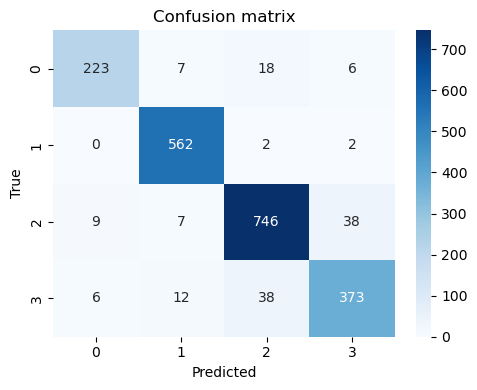

In [97]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_prep, y_train)

evaluate_model("KNN", knn, X_val_prep, y_val)


Random Forest
Accuracy:  0.8834
Precision: 0.8902
Recall:    0.8541
Macro-F1:  0.8689
ROC-AUC (OvR): 0.9806


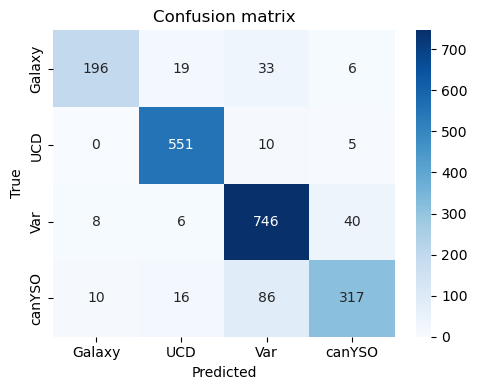

In [108]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,          
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_prep, y_train)

evaluate_model("Random Forest", rf, X_val_prep, y_val)


XGBoost
Accuracy:  0.9541
Precision: 0.9479
Recall:    0.9513
Macro-F1:  0.9495
ROC-AUC (OvR): 0.9939


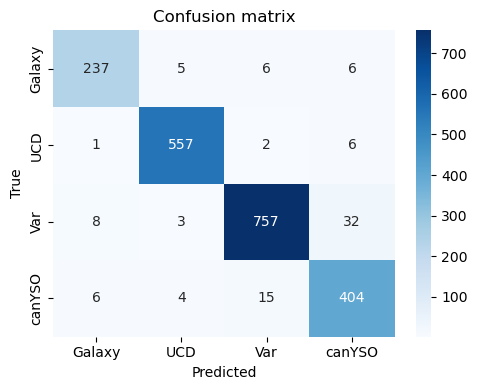

In [106]:
from xgboost import XGBClassifier

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train_prep, y_train_enc)

evaluate_model("XGBoost", xgb, X_val_prep, y_val) 


SVM (RBF)
Accuracy:  0.9341
Precision: 0.9273
Recall:    0.9267
Macro-F1:  0.9269
ROC-AUC (OvR): 0.9895


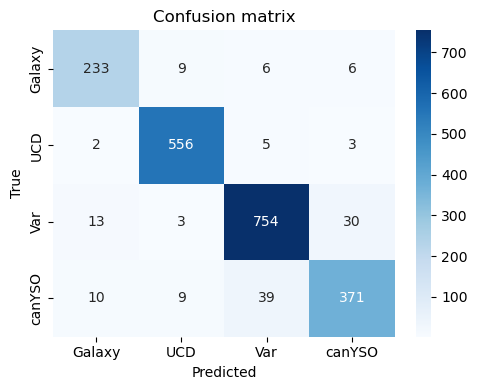

In [107]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_prep, y_train)

evaluate_model("SVM (RBF)", svm, X_val_prep, y_val)